<h3>Objective</h3>

The objective of the Assignment is to Follow the Data Science Methodology that we studied in Module 3. 

Analyse the data set and answer the following questions 

● Which city has a better sale for products in the Electronic Accessories product line. 

● Which payment method is used more often at a particular city, branch and for which product type 

● Which Product type has been more purchased by female customers 

● In which month does the highest number of home and lifestyle products have been sold 

● At what time most of the female customers are purchasing products. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [9]:
idf = pd.read_csv('RawData/Supermarket_Sales_Dataset.csv')
idf.head(5)


,Invoice ID,Branch,City,Customer Type,Gender,Product Type,Unit Price,Quantity,Tax,Selling Price,Date,Time,Payment Type,Cost Price,Gross Income,Rating
0,750-67-8428,A,Bangalore,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Debit card,522.83,26.1415,9.1
1,226-31-3081,C,Mysore,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,3.8200,9.6
2,631-41-3108,A,Bangalore,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,16.2155,7.4
3,123-19-1176,A,Bangalore,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Debit card,465.76,23.2880,8.4
4,373-73-7910,A,Bangalore,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Debit card,604.17,30.2085,5.3


In [10]:
# To understand the metadata of the loaded data
idf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice ID     1000 non-null   object 
 1   Branch         1000 non-null   object 
 2   City           1000 non-null   object 
 3   Customer Type  1000 non-null   object 
 4   Gender         1000 non-null   object 
 5   Product Type   1000 non-null   object 
 6   Unit Price     1000 non-null   float64
 7   Quantity       1000 non-null   int64  
 8   Tax            1000 non-null   float64
 9   Selling Price  1000 non-null   float64
 10  Date           1000 non-null   object 
 11  Time           1000 non-null   object 
 12  Payment Type   1000 non-null   object 
 13  Cost Price     1000 non-null   float64
 14  Gross Income   1000 non-null   float64
 15  Rating         1000 non-null   float64
dtypes: float64(6), int64(1), object(9)
memory usage: 125.1+ KB


In [13]:
# Checking the number of missing values in the available columns 
idf.isna().sum()

Invoice ID       0
Branch           0
City             0
Customer Type    0
Gender           0
Product Type     0
Unit Price       0
Quantity         0
Tax              0
Selling Price    0
Date             0
Time             0
Payment Type     0
Cost Price       0
Gross Income     0
Rating           0
dtype: int64

(array([102.,  93.,  89., 107., 108., 101., 105.,  99.,  91., 105.]),
 array([ 4. ,  4.6,  5.2,  5.8,  6.4,  7. ,  7.6,  8.2,  8.8,  9.4, 10. ]),
 <BarContainer object of 10 artists>)

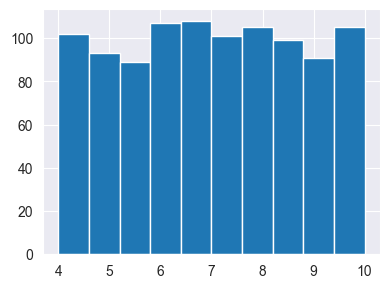

In [16]:
# Plotting graphs of number of occurrences of different rating values
import seaborn as sns

%matplotlib inline
sns.set_style('darkgrid')
plt.figure(figsize=(20,7))
plt.subplot(2,4,2)
plt.hist(idf.Rating)

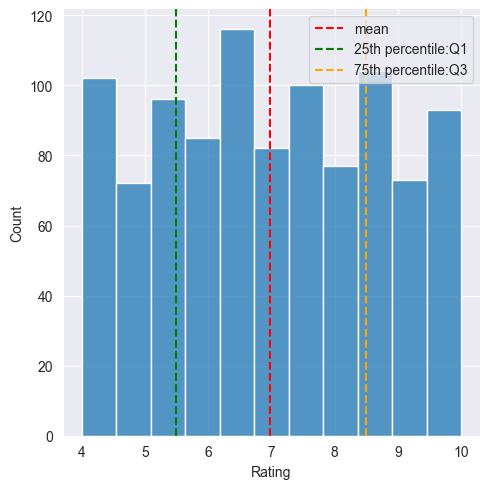

In [18]:
# Plotting graphs of distribution of different rating values
sns.displot(idf.Rating)
plt.axvline(x=np.mean(idf.Rating), c='red', ls='--', label='mean')
plt.axvline(x=np.percentile(idf.Rating,25),c='green', ls='--', label = '25th percentile:Q1')
plt.axvline(x=np.percentile(idf.Rating,75),c='orange', ls='--',label = '75th percentile:Q3' )
plt.legend()

<h3> Which Product type has been more purchased by female customers </h3>

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

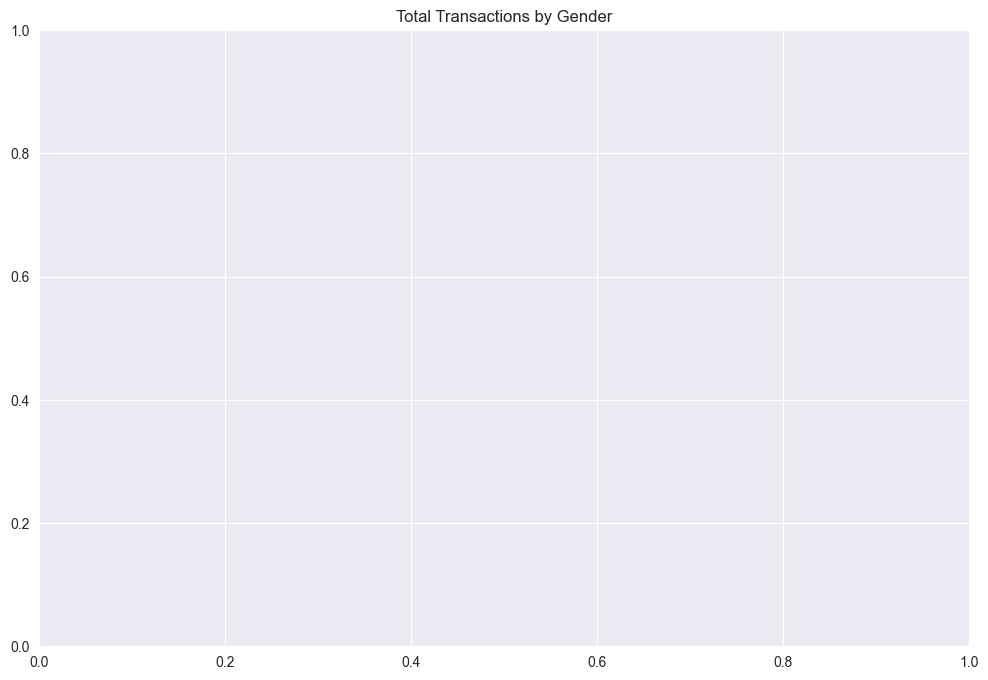

In [25]:
plt.figure(figsize=(12, 6))
plt.title('Total transactions by Gender')
sns.countplot(idf['Product Type'], hue = idf.Gender)

gender_dummies  = pd.get_dummies(idf['Gender'])
gender_dummies.head()

df1 = pd.concat([idf, gender_dummies], axis = 1)
df1.head()

plt.figure(figsize = (12,6))
sns.barplot(x = 'Product Type', y = 'Female', data = df1)